In [31]:
from tinyphysics import TinyPhysicsModel, TinyPhysicsSimulator, CONTROL_START_IDX
from controllers import pid, zero, pid_ref, custom, custom_v2, custom3, custom4, custom6, custom_pid, custom_pid2, pid_v2
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import random

sns.set_theme()


In [61]:
LIM = 500
def plot_rollout(sim):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    
    # First subplot: Lateral Acceleration
    ax1.plot(sim.target_lataccel_history[:LIM], label="Target Lateral Acceleration", alpha=0.5)
    ax1.plot(sim.current_lataccel_history[:LIM], label="Actual Lateral Acceleration", alpha=0.5)
    ax1.legend()
    ax1.set_ylabel("Lateral Acceleration")
    ax1.set_title("Rollout: Lateral Acceleration")
    
    # Second subplot: Control Action
    ax2.plot(sim.action_history[:LIM], label="Control Action", alpha=0.5)
    ax2.legend()
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Control Action")
    ax2.set_title("Rollout: Control Action")
    deltas = np.diff(sim.action_history[:LIM])
    
    plt.tight_layout()
    plt.show()

{'lataccel_cost': 1.6323720015479686, 'jerk_cost': 28.88882887354576, 'total_cost': 110.50742895094419}


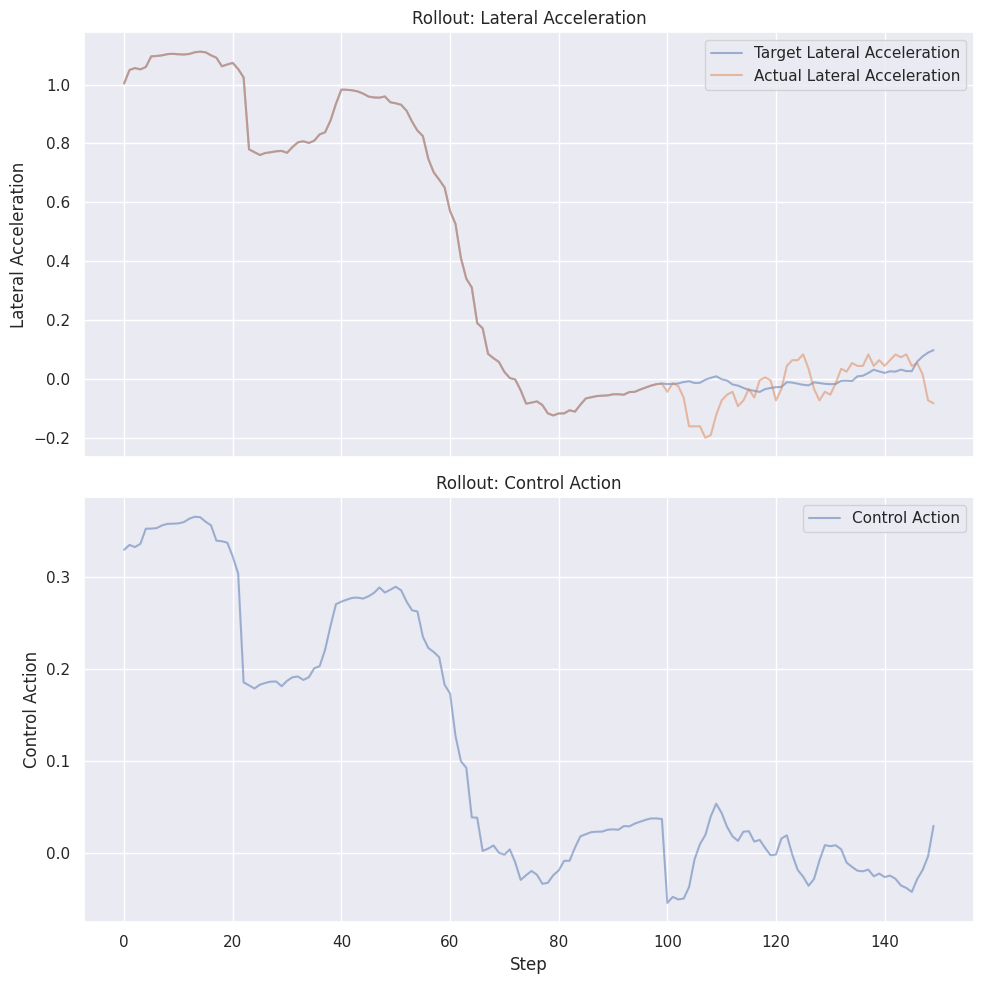

In [13]:
controller = pid.Controller()
sim = TinyPhysicsSimulator("./data/00000.csv", controller=controller, debug=False)
np.random.seed(random.randrange(100000))
print(sim.rollout())
plot_rollout(sim)

{'lataccel_cost': 1.3188775520290672, 'jerk_cost': 29.597765127536814, 'total_cost': 95.54164272899018}


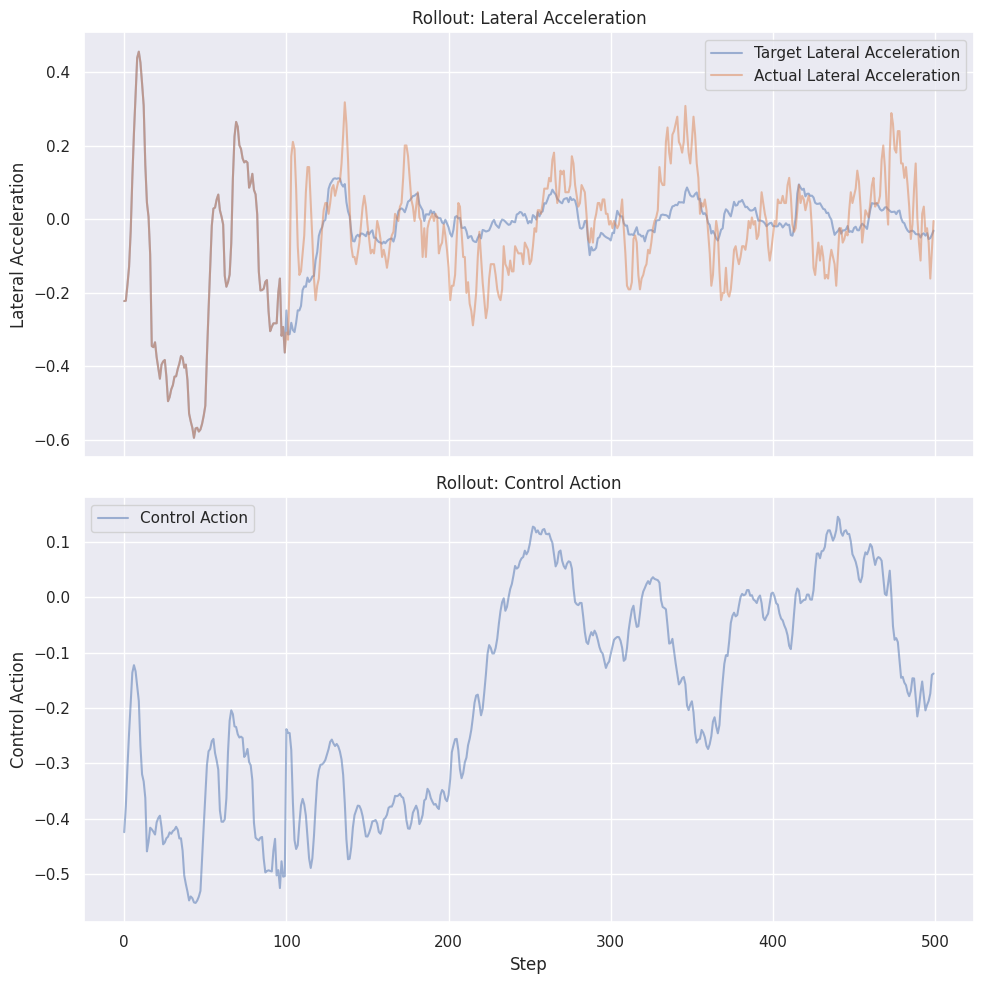

In [82]:
controller = pid_ref.Controller()
sim = TinyPhysicsSimulator("./data/00006.csv", controller=controller, debug=False)
np.random.seed(random.randrange(100000))
print(sim.rollout())
plot_rollout(sim)
ah = sim.action_history[100:]

In [84]:
print(f"{np.mean(ah):.3f} {np.std(ah):.3f}")
print(f"{np.min(ah):.3f} {np.max(ah):.3f}")


diff = np.diff(ah)
print(f"{np.mean(diff):.4f} {np.mean(abs(diff)):.4f} {np.std(diff):.4f}")
print(f"{np.min(diff):.3f} {np.max(diff):.3f}")
# count diffs with ||>0.05
print(np.sum(np.abs(diff) > 0))
print(np.sum(np.abs(diff) > 0.01))
print(np.sum(np.abs(diff) > 0.025))
print(np.sum(np.abs(diff) > 0.04))
print(np.sum(np.abs(diff) > 0.05))
print(np.sum(np.abs(diff) > 0.1))

-0.129 0.175
-0.489 0.146
0.0003 0.0134 0.0181
-0.094 0.053
399
195
60
11
6
0


100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
{'lataccel_cost': 1.0911231078597914, 'jerk_cost': 23.779406630376585, 'total_cost': 78.33556202336615}


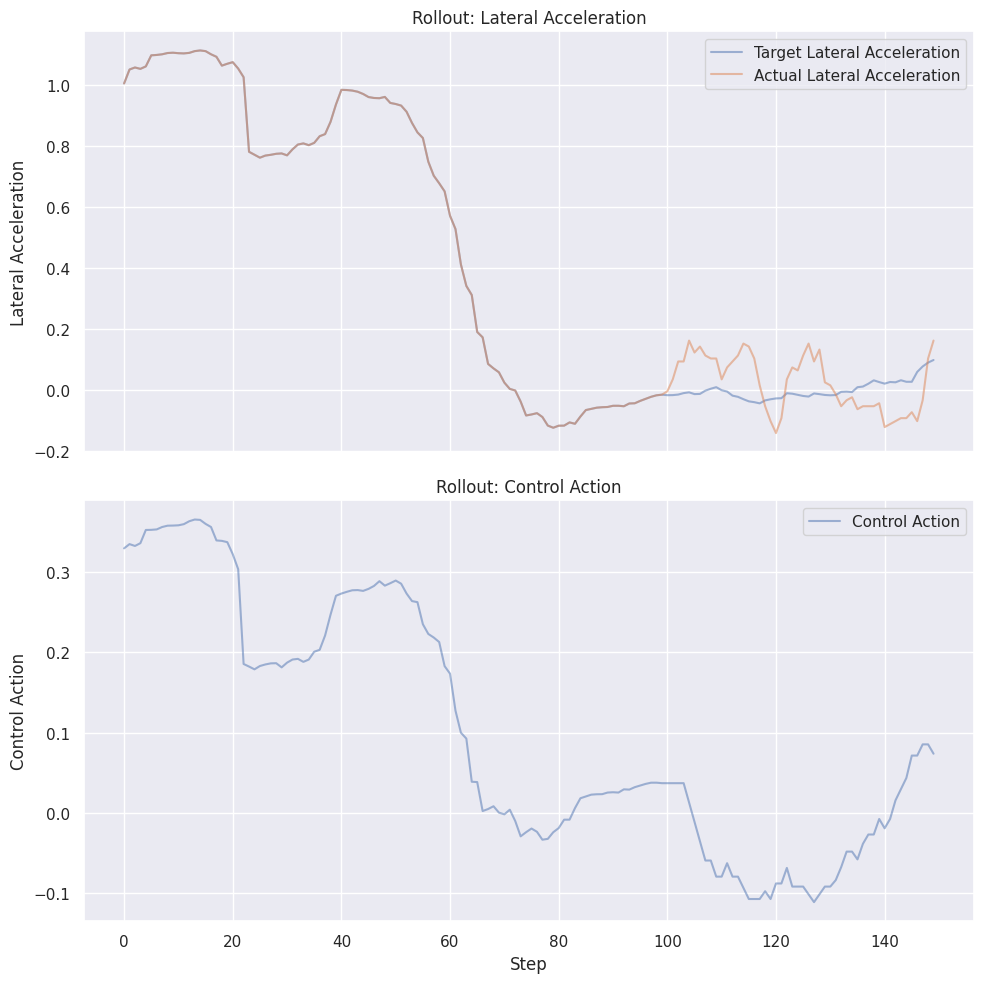

In [23]:
import importlib
importlib.reload(custom)
controller = custom.Controller()
sim = TinyPhysicsSimulator("./data/00000.csv", controller=controller, debug=False)
np.random.seed(random.randrange(100000))
if getattr(controller, "giveSim", None):
  controller.giveSim(sim)
print(sim.rollout(LIM))
plot_rollout(sim)

100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
{'lataccel_cost': 2.0778930888259435, 'jerk_cost': 18.829711017545986, 'total_cost': 122.72436545884317}


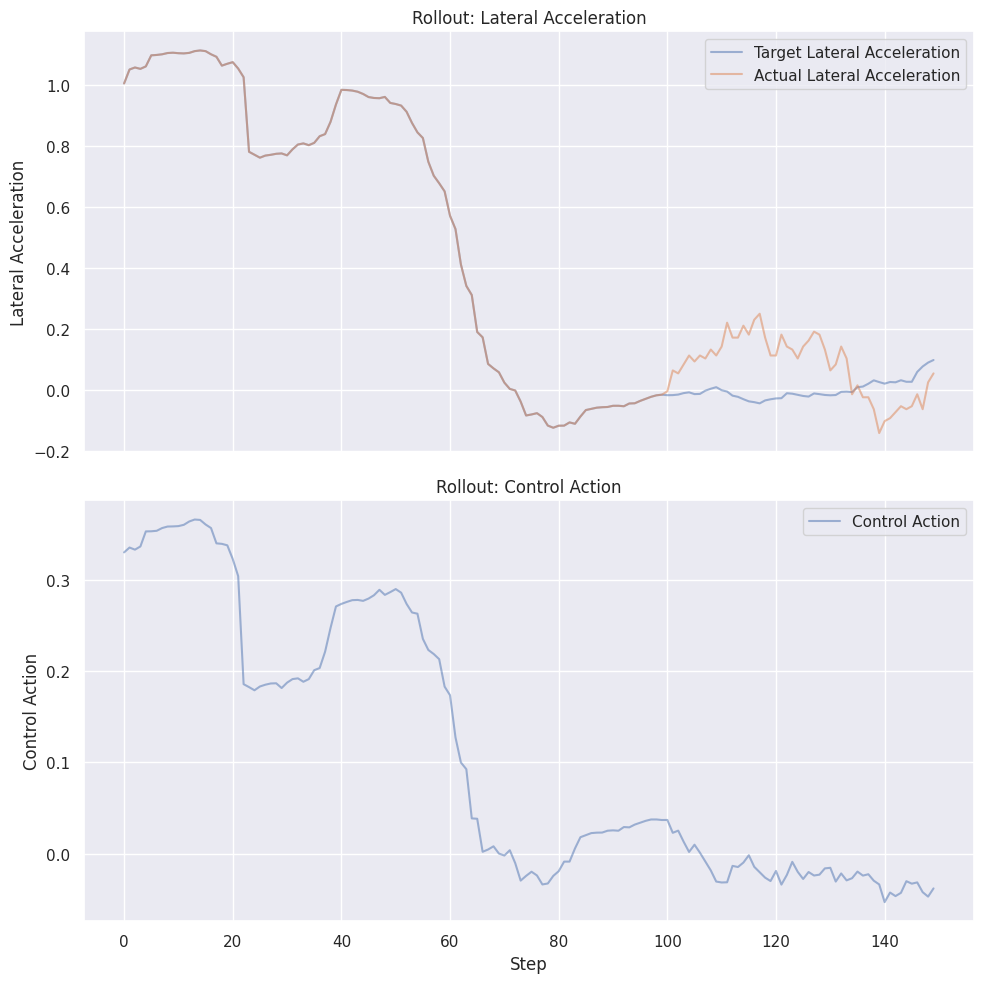

In [6]:
import importlib
importlib.reload(custom3)
controller = custom3.Controller()
sim = TinyPhysicsSimulator("./data/00000.csv", controller=controller, debug=False)
np.random.seed(random.randrange(100000))
if getattr(controller, "giveSim", None):
  controller.giveSim(sim)
print(sim.rollout(LIM))
plot_rollout(sim)

100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
{'lataccel_cost': 0.6176042293698394, 'jerk_cost': 18.947819710288357, 'total_cost': 49.82803117878032}


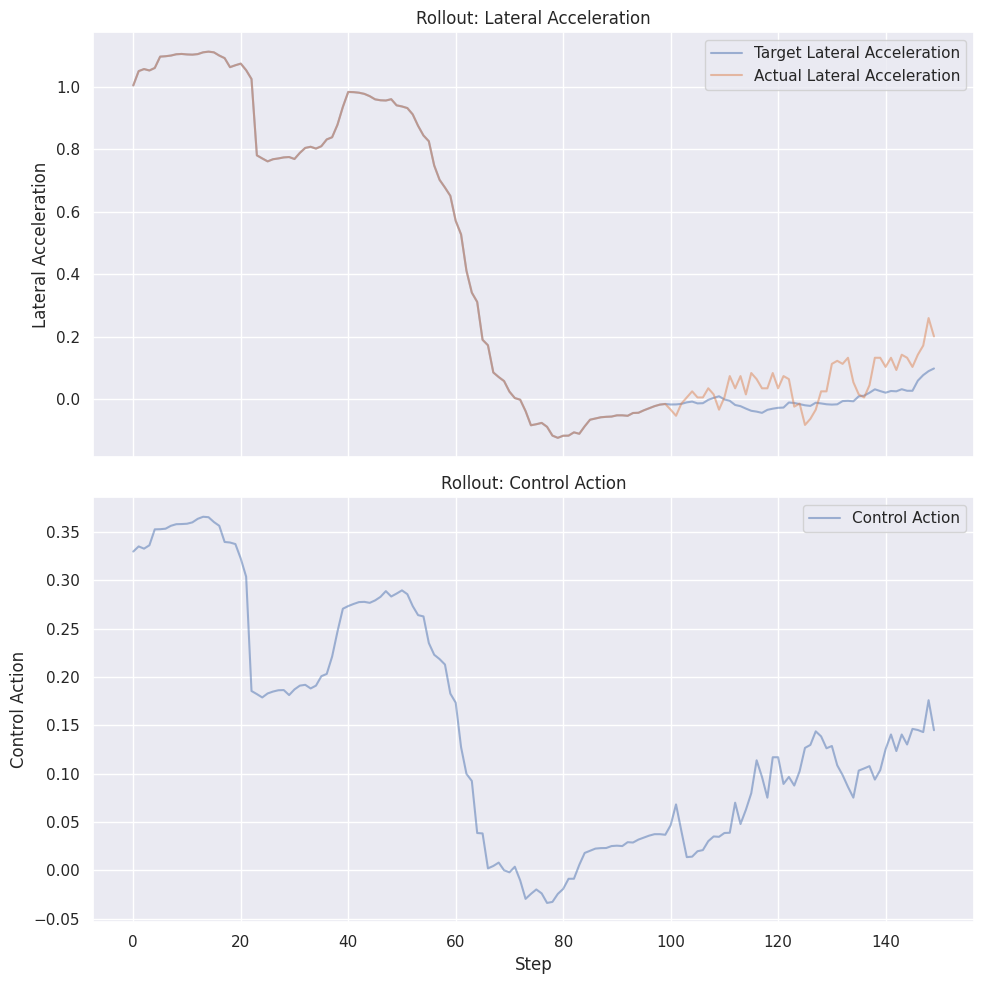

In [7]:
import importlib
importlib.reload(custom4)
controller = custom4.Controller()
sim = TinyPhysicsSimulator("./data/00000.csv", controller=controller, debug=False)
np.random.seed(random.randrange(100000))
if getattr(controller, "giveSim", None):
  controller.giveSim(sim)
print(sim.rollout(LIM))
plot_rollout(sim)

100
Mean: [-1.503  -7.7544 -1.007  -9.4085 -3.862 ]
Std: [16.0067 14.8646 17.2262 20.1941 25.2228]
Elite costs 29.949433635275046
Mean: [ -2.2557 -13.4274   2.7709 -16.7888   2.9669]
Std: [12.9755 19.1148 15.3069 13.0461 17.1735]
Elite costs 32.874401238049195
Mean: [ -8.8109  -7.2461  -3.1158 -15.474    5.9933]
Std: [15.1785 20.3681 15.3645 13.5945 12.5936]
Elite costs 27.435593160935753
Mean: [ -4.041   -5.0846  -9.0653 -23.8291   3.0053]
Std: [17.4437 12.2737  7.2747 12.2758  9.1634]
Elite costs 27.659039534209903
Mean: [ -6.474   -5.6698 -12.0413 -25.5099   5.8062]
Std: [11.1322 11.8128  8.3014 13.501  11.7081]
Elite costs 24.320649022949482
Mean: [ -9.6055  -5.6133 -13.0526 -22.6919   6.299 ]
Std: [12.4248  8.2971  6.5516  9.6714  7.7567]
Elite costs 24.97404811001355
Mean: [-20.9918  -2.7306 -13.1344 -22.7585   5.2173]
Std: [8.958  9.4497 4.6702 9.1406 8.4076]
Elite costs 27.18061672715653
Mean: [-21.096   -0.1493 -12.0893 -23.0787   8.0648]
Std: [ 6.5797  9.778   3.6104  8.7856 

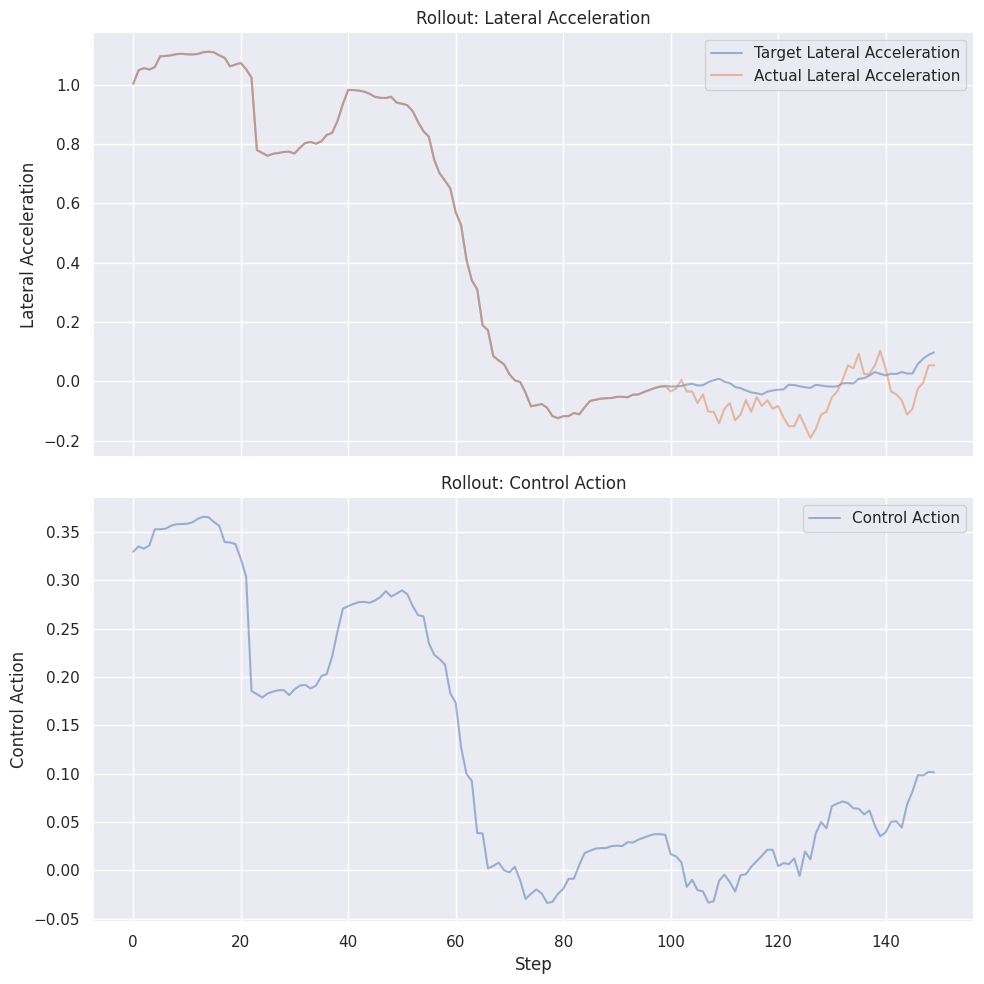

In [8]:
import importlib
importlib.reload(custom6)
controller = custom6.Controller()
sim = TinyPhysicsSimulator("./data/00000.csv", controller=controller, debug=False)
np.random.seed(random.randrange(100000))
if getattr(controller, "giveSim", None):
  controller.giveSim(sim)
print(sim.rollout(LIM))
plot_rollout(sim)

100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
{'lataccel_cost': 1.362613086550799, 'jerk_cost': 21.03267460093865, 'total_cost': 89.1633289284786}


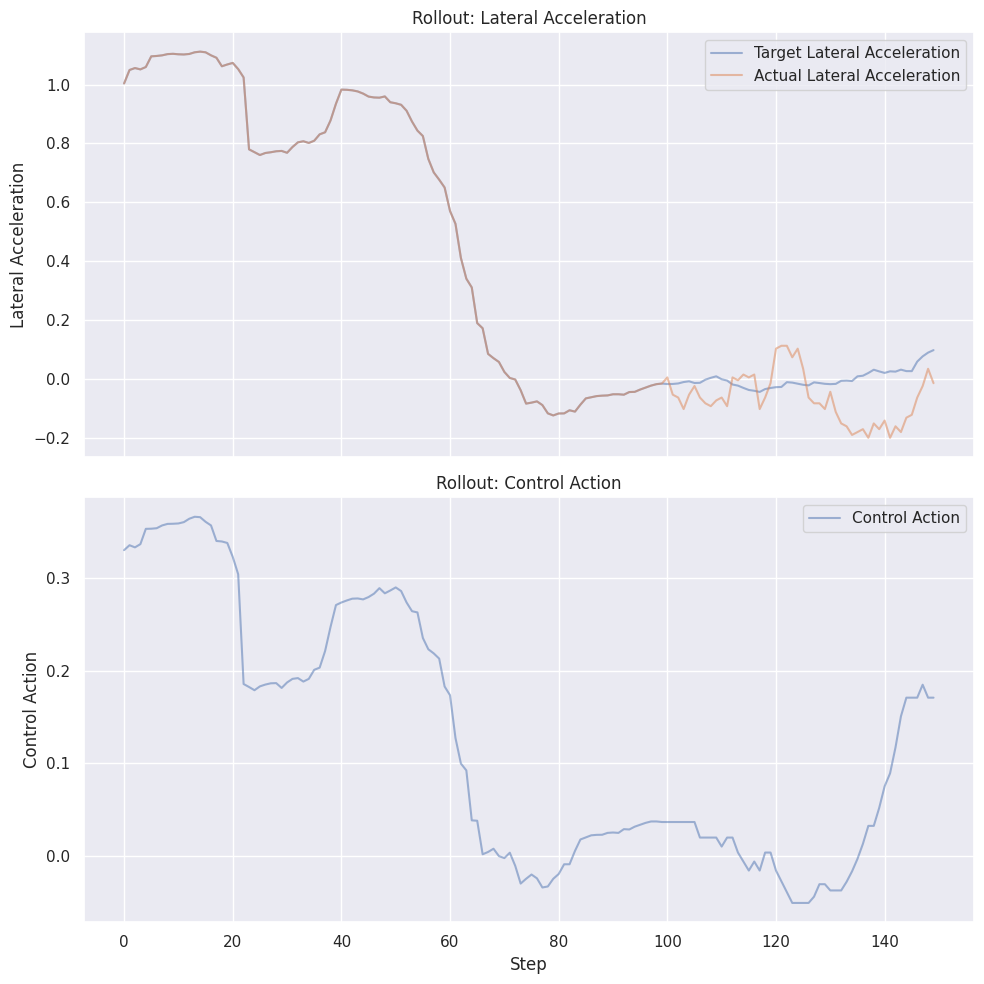

In [30]:
import importlib
importlib.reload(custom_pid)
controller = custom_pid.Controller()
sim = TinyPhysicsSimulator("./data/00000.csv", controller=controller, debug=False)
np.random.seed(random.randrange(100000))
if getattr(controller, "giveSim", None):
  controller.giveSim(sim)
print(sim.rollout(LIM))
plot_rollout(sim)

In [4]:
import importlib
importlib.reload(custom_pid2)
controller = custom_pid2.Controller()
sim = TinyPhysicsSimulator("./data/00000.csv", controller=controller, debug=False)
np.random.seed(random.randrange(100000))
if getattr(controller, "giveSim", None):
  controller.giveSim(sim)
print(sim.rollout(LIM))
plot_rollout(sim)

100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115


KeyboardInterrupt: 

{'lataccel_cost': 0.8031886011931694, 'jerk_cost': 33.43633683268808, 'total_cost': 73.59576689234655}


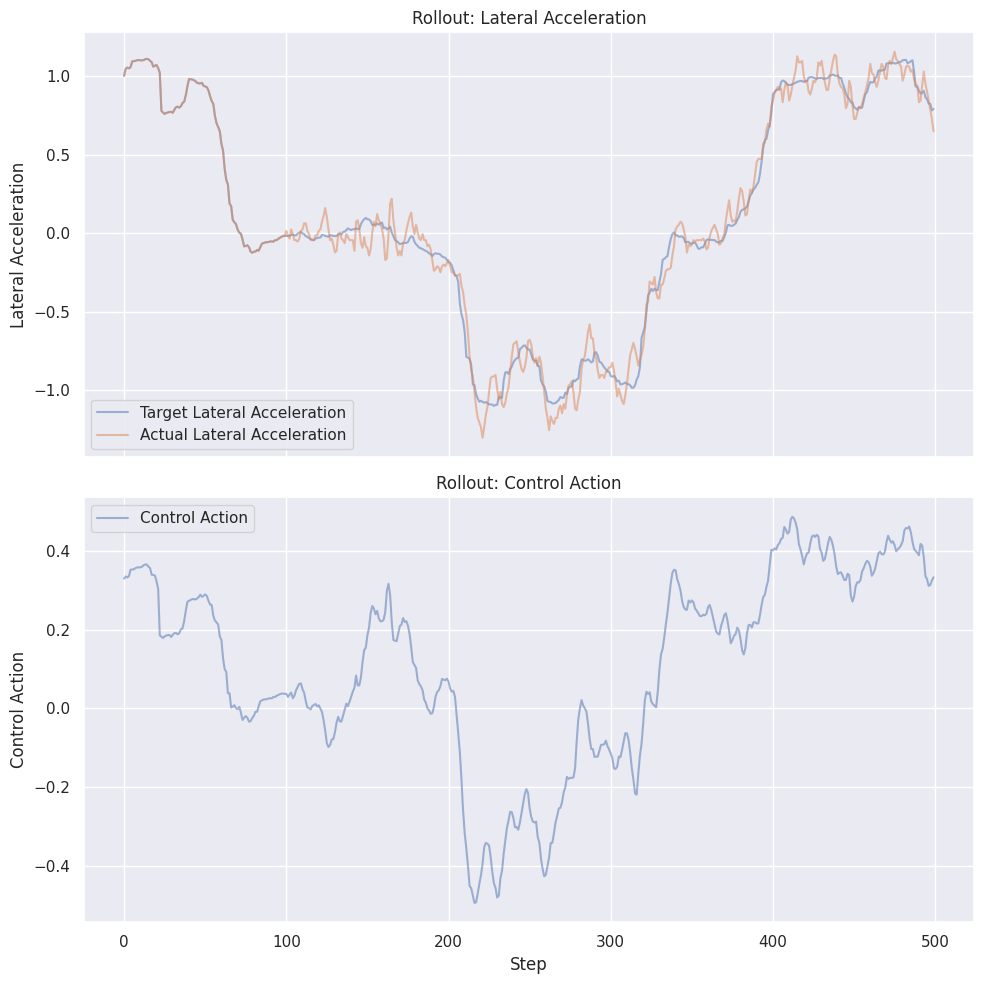

In [30]:
import importlib
importlib.reload(pid_v2)
controller = pid_v2.Controller()
sim = TinyPhysicsSimulator("./data/00000.csv", controller=controller, debug=False)
np.random.seed(random.randrange(100000))
if getattr(controller, "giveSim", None):
  controller.giveSim(sim)
LIM = 500
print(sim.rollout(LIM))
plot_rollout(sim)